In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
# Q1. Dataset Overview

In [5]:
import pandas as pd
df = pd.read_csv("agriculture_yield_dataset.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [7]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(1500, 8)


In [9]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']


In [11]:
df.head(10)

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


In [13]:
# Q2. Data Types and Missing Values

In [15]:
print(df.dtypes)

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                    str
soil_type                    str
yield_ton_per_hectare    float64
dtype: object


In [17]:
print(df.isnull().sum())

rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [19]:
missing_cols = df.columns[df.isnull().sum() > 0]
if len(missing_cols) > 0:
    print("Columns with missing values:")
    print(missing_cols)
else:
    print("No missing values found.")

No missing values found.


In [21]:
# Q3. Descriptive Statistics

In [23]:
summary = df.describe()
summary

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


In [25]:
means = df.mean(numeric_only=True)
stds = df.std(numeric_only=True)
print("Highest Mean Feature:")
print(means.idxmax(), "=", means.max())
print("\nHighest Standard Deviation Feature:")
print(stds.idxmax(), "=", stds.max())

Highest Mean Feature:
rainfall_mm = 754.0546666666667

Highest Standard Deviation Feature:
rainfall_mm = 255.0972161445094


In [27]:
# Q4. Distribution Analysis

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

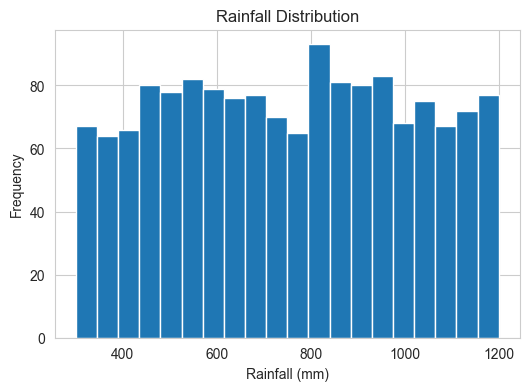

In [31]:
plt.figure(figsize=(6,4))
plt.hist(df['rainfall_mm'], bins=20)
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

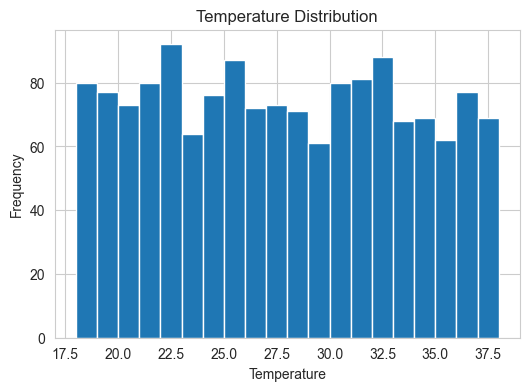

In [33]:
plt.figure(figsize=(6,4))
plt.hist(df['temperature_c'], bins=20)
plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.show()

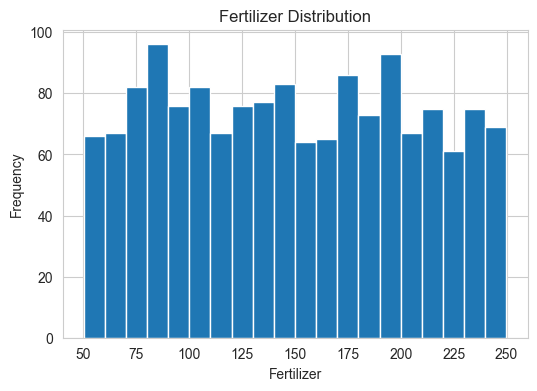

In [35]:
plt.figure(figsize=(6,4))
plt.hist(df['fertilizer_kg'], bins=20)
plt.title("Fertilizer Distribution")
plt.xlabel("Fertilizer")
plt.ylabel("Frequency")
plt.show()

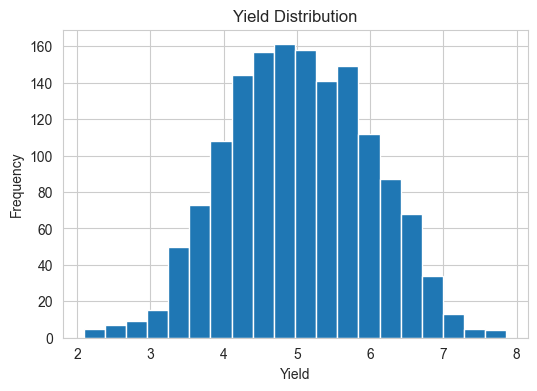

In [37]:
plt.figure(figsize=(6,4))
plt.hist(df['yield_ton_per_hectare'], bins=20)
plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

In [39]:
# Q5. Crop Type Analysis

In [41]:
crop_counts = df['crop_type'].value_counts()
crop_counts

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64

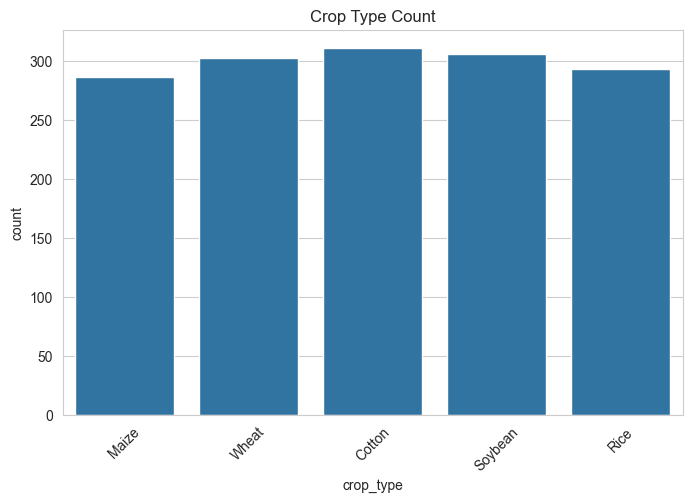

In [43]:
plt.figure(figsize=(8,5))
sns.countplot(x='crop_type', data=df)
plt.title("Crop Type Count")
plt.xticks(rotation=45)
plt.show()

In [45]:
print("Most Frequent Crop:")
print(crop_counts.idxmax())

Most Frequent Crop:
Cotton


In [47]:
# Q6. Soil Type Analysis

In [49]:
soil_counts = df['soil_type'].value_counts()
soil_counts

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64

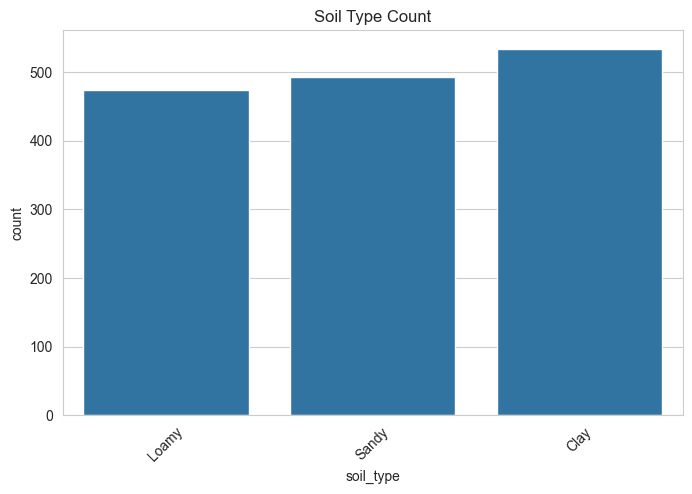

In [51]:
plt.figure(figsize=(8,5))
sns.countplot(x='soil_type', data=df)
plt.title("Soil Type Count")
plt.xticks(rotation=45)
plt.show()

In [53]:
print("Most Common Soil:")
print(soil_counts.idxmax())

Most Common Soil:
Clay


In [55]:
# Q7. Yield Distribution

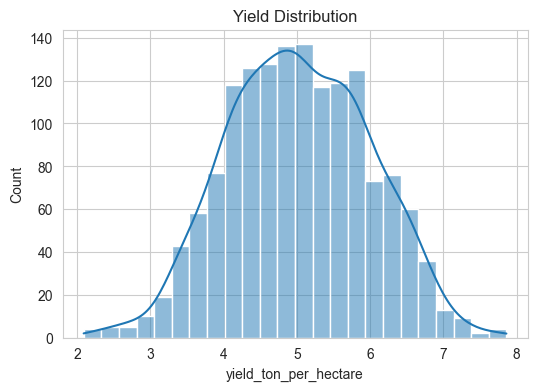

In [57]:
plt.figure(figsize=(6,4))
sns.histplot(df['yield_ton_per_hectare'], kde=True)
plt.title("Yield Distribution")
plt.show()

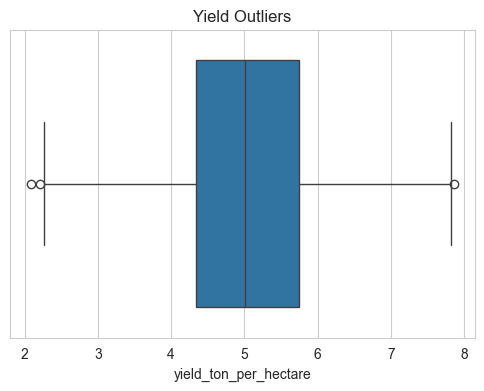

In [59]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['yield_ton_per_hectare'])
plt.title("Yield Outliers")
plt.show()

In [61]:
# Q8. Scatter Plot Analysis

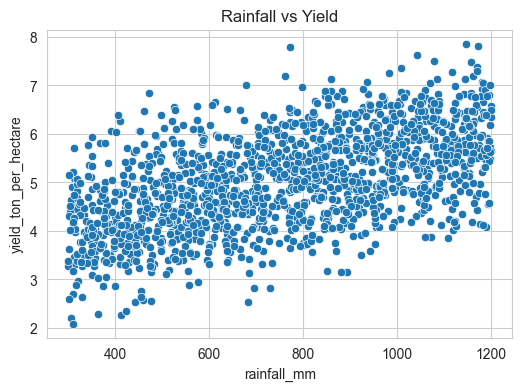

In [63]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='rainfall_mm',
    y='yield_ton_per_hectare',
    data=df
)
plt.title("Rainfall vs Yield")
plt.show()

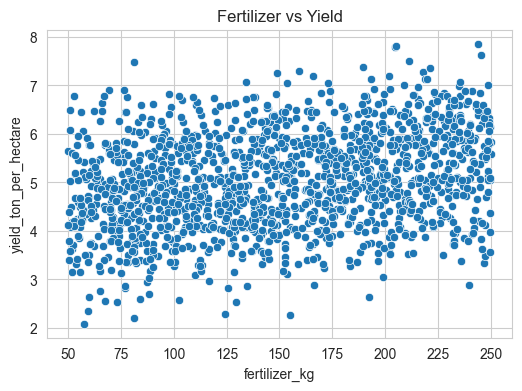

In [65]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='fertilizer_kg',
    y='yield_ton_per_hectare',
    data=df
)
plt.title("Fertilizer vs Yield")
plt.show()

In [67]:
print("Rainfall Correlation:")
print(df['rainfall_mm'].corr(df['yield_ton_per_hectare']))
print()
print("Fertilizer Correlation:")
print(df['fertilizer_kg'].corr(df['yield_ton_per_hectare']))

Rainfall Correlation:
0.5537042408932247

Fertilizer Correlation:
0.2780425888693049


In [69]:
# Q9. Correlation Analysis

In [71]:
corr_matrix = df.select_dtypes(include='number').corr()
corr_matrix

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
rainfall_mm,1.000000,0.026721,0.002558,0.010877,0.006916,0.553704
temperature_c,0.026721,1.000000,0.037468,0.007114,0.001513,-0.022559
fertilizer_kg,0.002558,0.037468,1.000000,-0.010497,0.010001,0.278043
irrigation_hours,0.010877,0.007114,-0.010497,1.000000,0.009307,0.542664
soil_ph,0.006916,0.001513,0.010001,0.009307,1.000000,0.024412
yield_ton_per_hectare,0.553704,-0.022559,0.278043,0.542664,0.024412,1.000000


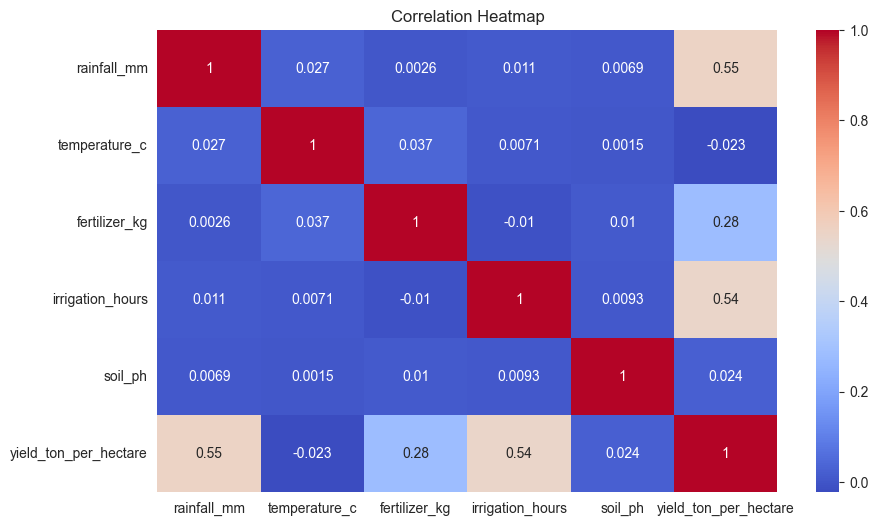

In [73]:
plt.figure(figsize=(10,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

In [75]:
yield_corr = corr_matrix['yield_ton_per_hectare']
top3 = yield_corr.abs().sort_values(ascending=False)
top3.head(4)

yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
Name: yield_ton_per_hectare, dtype: float64

In [77]:
# Q10. Group-Based Analysis

In [79]:
crop_yield = df.groupby('crop_type')['yield_ton_per_hectare'].mean()
crop_yield

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

In [81]:
soil_yield = df.groupby('soil_type')['yield_ton_per_hectare'].mean()
soil_yield

soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

In [83]:
print("Highest Yield Crop:")
print(crop_yield.idxmax())
print()
print("Highest Yield Soil:")
print(soil_yield.idxmax())

Highest Yield Crop:
Rice

Highest Yield Soil:
Loamy


In [85]:
# Q11. Feature Encoding

In [87]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['crop_type', 'soil_type'], dtype='str')


/var/folders/0n/bb75wrdx20bcr5tp8fbc28sh0000gn/T/ipykernel_15638/4182786301.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [89]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)
df_encoded.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


In [91]:
df_encoded.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


In [93]:
# Q12. Feature Selection

In [95]:
X = df_encoded.drop(
    'yield_ton_per_hectare',
    axis=1
)
y = df_encoded['yield_ton_per_hectare']
print("Target Variable:")
print("yield_ton_per_hectare")

Target Variable:
yield_ton_per_hectare


In [97]:
print(X.shape)
print(y.shape)

(1500, 11)
(1500,)


In [99]:
# Q13. Train-Test Split

In [101]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [103]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1200, 11)
X_test : (300, 11)
y_train: (1200,)
y_test : (300,)


In [105]:
# Q14. Linear Regression Model

In [107]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
print("Model Trained Successfully")

Model Trained Successfully


In [109]:
print("Intercept:")
print(model.intercept_)
print("\nCoefficients:")
print(model.coef_)

Intercept:
1.5871320277361205

Coefficients:
[ 0.00203545 -0.00917496  0.00497799  0.19832728  0.00490119  0.23893088
  0.86399284  0.48171939  0.34847403  0.30297421 -0.49093272]


In [111]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
6,crop_type_Rice,0.863993
7,crop_type_Soybean,0.481719
8,crop_type_Wheat,0.348474
9,soil_type_Loamy,0.302974
5,crop_type_Maize,0.238931
3,irrigation_hours,0.198327
2,fertilizer_kg,0.004978
4,soil_ph,0.004901
0,rainfall_mm,0.002035
1,temperature_c,-0.009175


In [113]:
highest_feature = coef_df.loc[
    coef_df['Coefficient'].idxmax()
]
print(highest_feature)

Feature        crop_type_Rice
Coefficient          0.863993
Name: 6, dtype: object
